Centering and scaling data matrix

Quantiles for the number of genes detected by cell: 
(Non-detected genes are shuffled at the end of the ranking. Keep it in mind when choosing the threshold for calculating the AUC).



    min      1%      5%     10%     50%    100% 
  200.0   502.0   726.9   861.0  1891.0 13612.0 


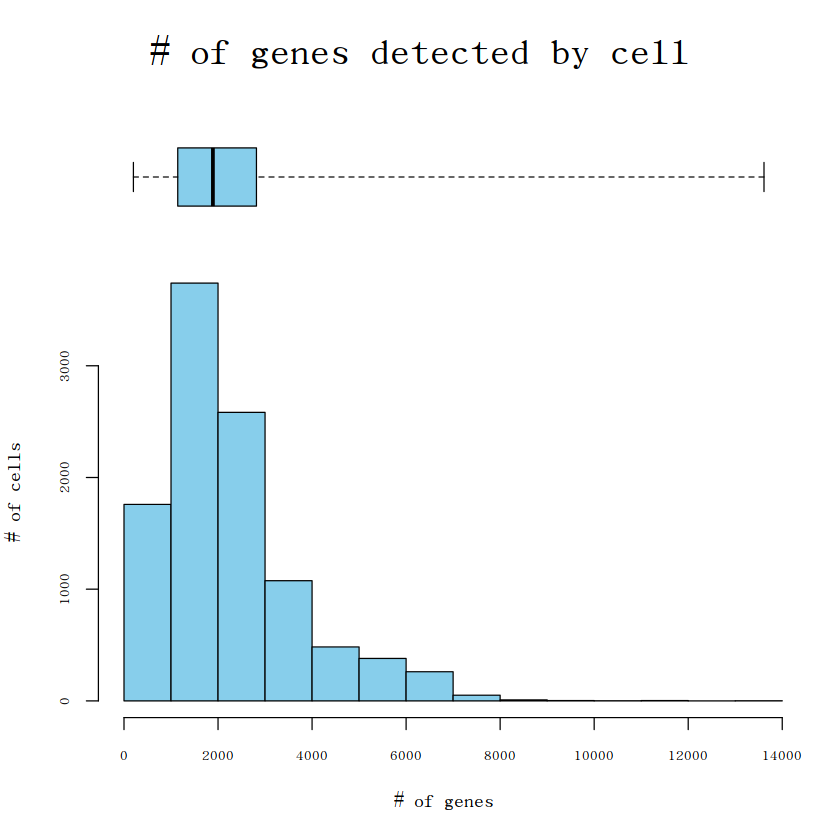

In [5]:
library(Seurat)
library(AUCell)


RNA_count <- Matrix::readMM("./ComicGTN/data/MOGHE_brain/Oligo_type/Oligo_Gene_Cell.mtx")
Gene_names <- read.csv("./ComicGTN/data/MOGHE_brain/Oligo_type/Oligo_gene_names.tsv", header = FALSE, sep = ",")
Cell_names <- read.table("./ComicGTN/data/MOGHE_brain/Oligo_type/Oligo_cell_names.tsv", header = FALSE, sep = ",")
Cell_types <- read.table("./ComicGTN/data/MOGHE_brain/Oligo_type/Oligo_cell_types.tsv", header = FALSE, sep = ",")


RNA_count <- as(RNA_count, "dgCMatrix")
colnames(RNA_count) <- Cell_names$V1
rownames(RNA_count) <- Gene_names$V1
rownames(Cell_types) <- Cell_names$V1
rownames(Gene_names) <- Gene_names$V1
names(Gene_names)<-c("gene_short_name")


Oligo_cluster <- CreateSeuratObject(counts = RNA_count)
Oligo_cluster$cell_types <- Cell_types$V1
Oligo_cluster<- NormalizeData(Oligo_cluster, normalization.method = "LogNormalize", scale.factor = 10000)
Oligo_cluster <- FindVariableFeatures(Oligo_cluster, selection.method = "vst", nfeatures = 2000)
Oligo_cluster <- ScaleData(Oligo_cluster, features = VariableFeatures(Oligo_cluster))
exprMatrix <- Oligo_cluster@assays$RNA@counts
cell_ranking <- AUCell_buildRankings(exprMatrix, plotStats = TRUE)


GOGeneList <- list("Central Nervous System Myelination" = c("CNTN2", "PLP1", "PTEN", "CLU", "CNTN1", "TENM4", "ABCA2", "SOX10", 
                                                                                                    "HES5", "MYRF", "B4GALT6", "MAL", "CNTNAP1", "KCNJ10", "GPM6B", 
                                                                                                    "MIOS", "FA2H", "ERCC2", "ID4", "MAG", "B4GALT5", "NCSTN"),
                                "Long-Term Synaptic Potentiation" = c("SLC8A2", "SLC8A3", "SLC24A2", "GRIN2A", "CALM1", "CALM2", "CALM3", 
                                                                                               "CAMK2A", "S100B", "STX3", "GFAP", "MAPK1", "NTRK2", "SNCA", "PRKCG",
                                                                                               "RGS14", "GRIA3", "NFATC4", "MPP2"),
                                "Transmembrane Transporter Binding" = c("ANK2", "ROBO2", "DPP10", "CBARP", "STK39", "CALM2"),
                                "Galactosylceramide Biosynthetic Process" = c("GAL3ST1", "UGT8", "FA2H", "B3GALT1", "B3GALT2", "B4GALT3"))

GOGeneSet <- c()
GeneSet <- function(x, setName){
    l <- list(x) 
    names(l) <- setName 
    return(l)}

for(i in 1:length(GOGeneList)){
    GOGeneSet <- c(GOGeneSet, GeneSet(GOGeneList[[i]], setName = names(GOGeneList)[i]))}


cell_AUC <- AUCell_calcAUC(GOGeneSet, cell_ranking)
AUCell_auc1 <- round(as.numeric(getAUC(cell_AUC)["Central Nervous System Myelination", ]), digits = 6)
AUCell_auc2 <- round(as.numeric(getAUC(cell_AUC)["Long-Term Synaptic Potentiation", ]), digits = 6)
AUCell_auc3 <- round(as.numeric(getAUC(cell_AUC)["Transmembrane Transporter Binding", ]), digits = 6)
AUCell_auc4 <- round(as.numeric(getAUC(cell_AUC)["Galactosylceramide Biosynthetic Process", ]), digits = 6)
AUCell_df <- data.frame("Central Nervous System Myelination" = AUCell_auc1, "Long-Term Synaptic Potentiation" = AUCell_auc2,
                                        "Transmembrane Transporter Binding" = AUCell_auc3, "Galactosylceramide Biosynthetic Process" = AUCell_auc4, 
                                        check.names = FALSE)
write.csv(AUCell_df, file = "./ComicGTN/data/MOGHE_brain/Oligo_type/AUCell.csv", row.names = FALSE)